# Data Description

There are 8 variables: 

- mpg: miles per gallon
- cyl: number of cylinders
- disp: engine displacement (cu. inches) or engine size
- hp: horsepower
- wt: vehicle weight (lbs.)
- acc: time taken to accelerate from O to 60 mph (sec.)
- yr: model year (modulo 100)
- origin: origin of car (1 - American, 2 - European, 3 - Japanese)
- car name: car model name 

Missing data values are marked by series of question marks.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit from the number of displayed columns
pd.set_option("display.max_columns", None)
# Changes the limit of number of displayed rows to 200
pd.set_option("display.max_rows", 200)

from scipy.stats import zscore

from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA

In [2]:
data = pd.read_csv('car-mpg.csv')
data.head()

,mpg,cyl,disp,hp,wt,acc,yr,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
cData = data.copy()
cData = cData.drop(['car name','origin'], axis=1)
cData.head()

,mpg,cyl,disp,hp,wt,acc,yr
0,18.0,8,307.0,130,3504,12.0,70
1,15.0,8,350.0,165,3693,11.5,70
2,18.0,8,318.0,150,3436,11.0,70
3,16.0,8,304.0,150,3433,12.0,70
4,17.0,8,302.0,140,3449,10.5,70


In [4]:
# rename the columns
cData.columns = ['mpg',
                 'cylinders',
                 'displacement',
                 'horsepower',
                 'weight',
                 'acceleration',
                 'year']

In [5]:
cData.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year'],
      dtype='object')

### Dealing with Missing Values

In [6]:
cData.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
dtype: int64

In [7]:
# check whether horsepower column has non-digit values
hpIsDigit = pd.DataFrame(cData['horsepower'].str.isdigit())

cData[hpIsDigit['horsepower']==False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,year
32,25.0,4,98.0,?,2046,19.0,71
126,21.0,6,200.0,?,2875,17.0,74
330,40.9,4,85.0,?,1835,17.3,80
336,23.6,4,140.0,?,2905,14.3,80
354,34.5,4,100.0,?,2320,15.8,81
374,23.0,4,151.0,?,3035,20.5,82


In [8]:
# Chnage the ? values to NaN for later cleanup
cData = cData.replace('?', np.nan)
cData[hpIsDigit['horsepower']==False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,year
32,25.0,4,98.0,NaN,2046,19.0,71
126,21.0,6,200.0,NaN,2875,17.0,74
330,40.9,4,85.0,NaN,1835,17.3,80
336,23.6,4,140.0,NaN,2905,14.3,80
354,34.5,4,100.0,NaN,2320,15.8,81
374,23.0,4,151.0,NaN,3035,20.5,82


In [9]:
# checking median values of columns
cData.median(numeric_only=True)

mpg               23.0
cylinders          4.0
displacement     148.5
weight          2803.5
acceleration      15.5
year              76.0
dtype: float64

In [10]:
cData['horsepower'] = cData['horsepower'].astype('float64')  # converting the hp column from object / string type to float

In [11]:
# replace missing values with the median value
cData = cData.fillna(cData.median(numeric_only=True))

In [12]:
cData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   year          398 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 21.9 KB


### Bivariate Analysis

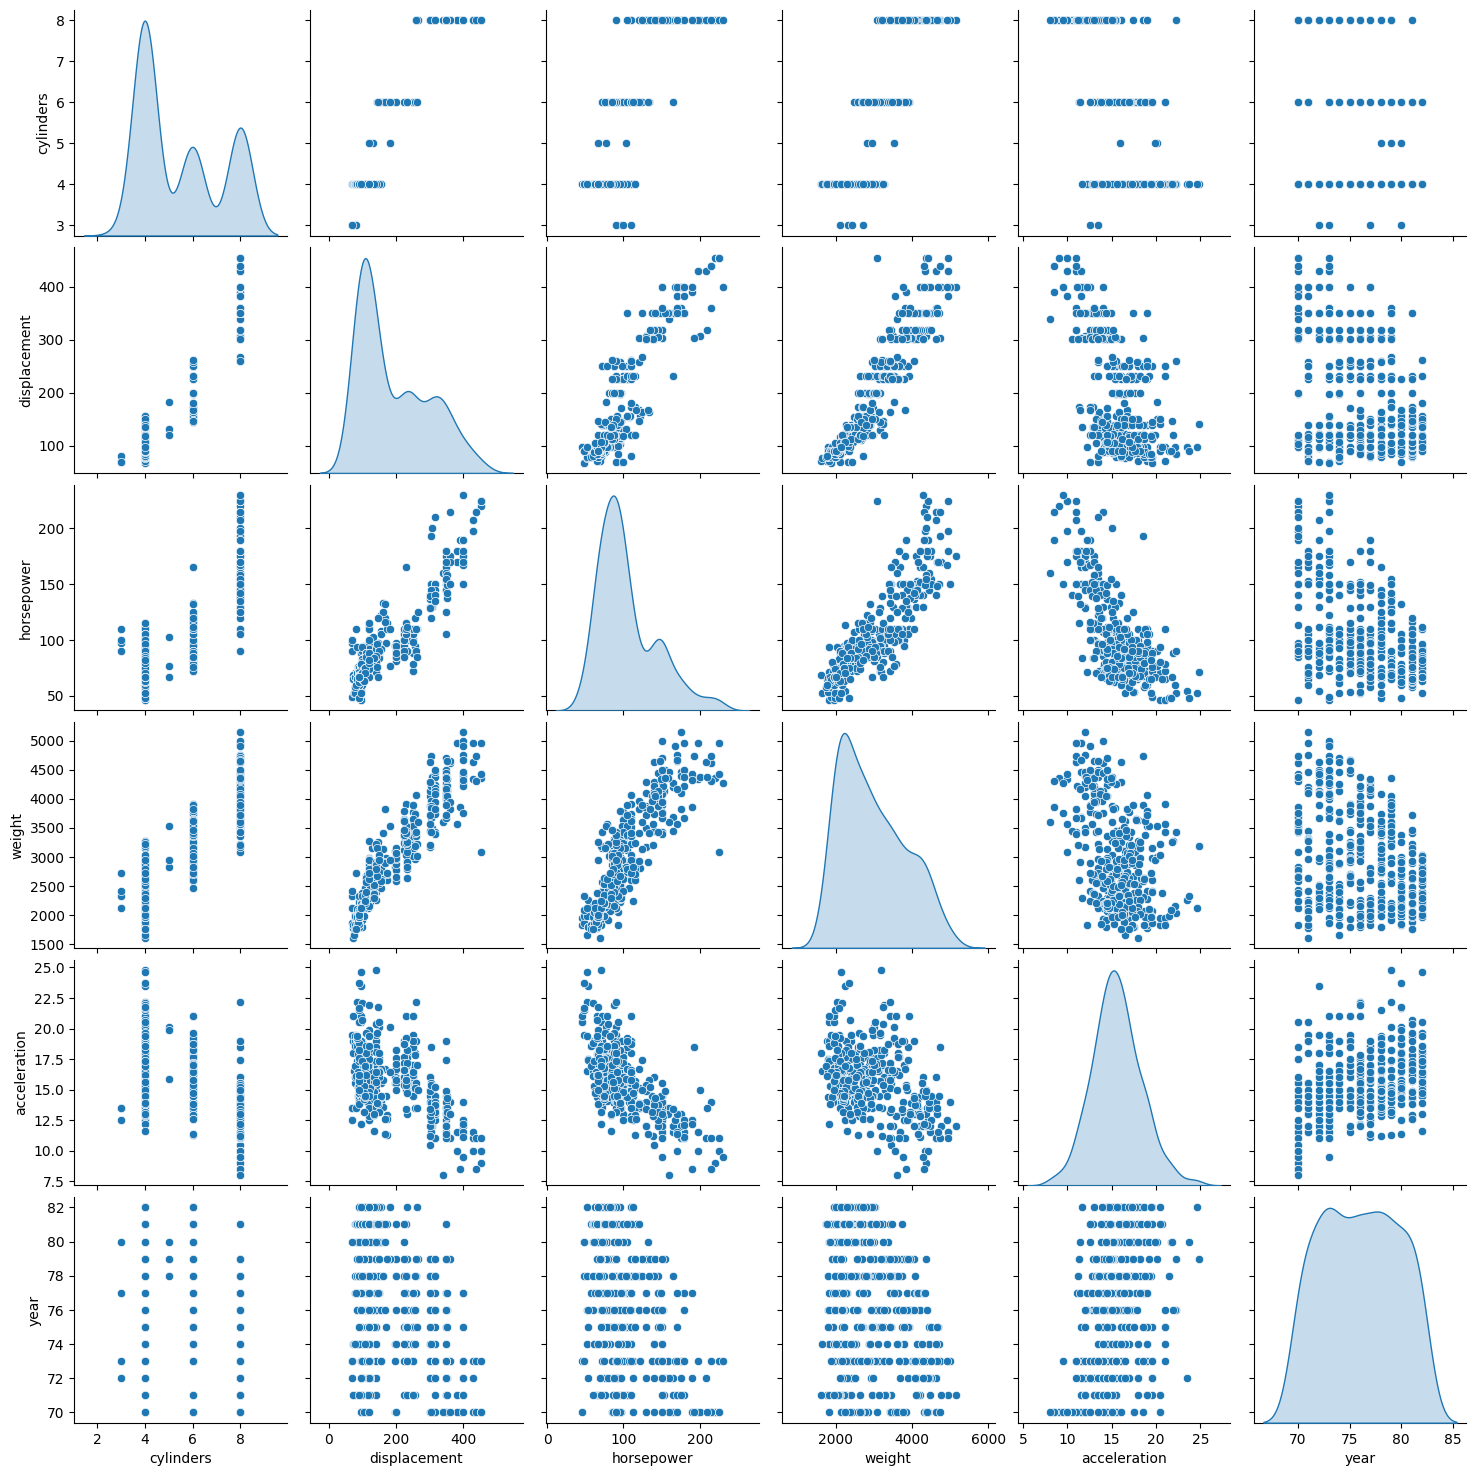

In [13]:
df = cData.drop(['mpg'], axis=1)
y = cData['mpg']
sns.pairplot(df,
             diag_kind='kde')

In [14]:
X = df.apply(zscore)
X.head()

,cylinders,displacement,horsepower,weight,acceleration,year
0,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426
1,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426
2,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426
3,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426
4,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426


### Applying t-SNE technique

In [15]:
cData[hpIsDigit['horsepower']==False]

,mpg,cylinders,displacement,horsepower,weight,acceleration,year
32,25.0,4,98.0,93.5,2046,19.0,71
126,21.0,6,200.0,93.5,2875,17.0,74
330,40.9,4,85.0,93.5,1835,17.3,80
336,23.6,4,140.0,93.5,2905,14.3,80
354,34.5,4,100.0,93.5,2320,15.8,81
374,23.0,4,151.0,93.5,3035,20.5,82


In [16]:
tsne = TSNE(n_components=2, random_state=8)
X_reduced = tsne.fit_transform(X)

In [17]:
X_reduced.shape

(398, 2)

In [18]:
reduced_data_df = pd.DataFrame(
    data=X_reduced,
    columns = ['Component 1','Component 2'])

In [19]:
reduced_data_df.tail()

,Component 1,Component 2
393,-10.706361,-1.350109
394,-20.299318,9.747724
395,-14.635623,-2.268473
396,-10.438127,4.525070
397,-9.639888,4.890567


<Axes: xlabel='Component 1', ylabel='Component 2'>

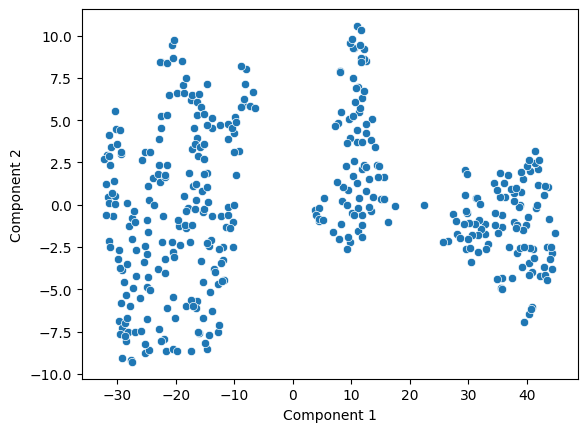

In [22]:
sns.scatterplot(
    x=reduced_data_df.iloc[:,0],
    y=reduced_data_df.iloc[:,1])

<Axes: xlabel='Component 1', ylabel='Component 2'>

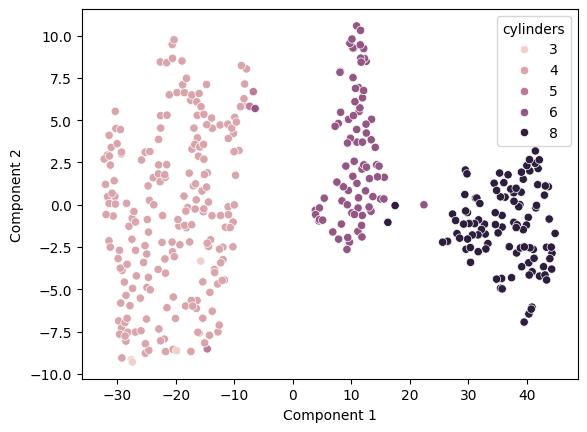

In [23]:
# Lets see scatter plot of the data w.r.t number of cyinders
sns.scatterplot(x=reduced_data_df.iloc[:,0],y=reduced_data_df.iloc[:,1],hue=cData.cylinders)

**Observations**

- 3 different groups of observations are visible.
- Cars with larger numbers of cylinders (8) seem to be in one group, cars with small number of cylinders (3,4) seem to be in different group, and cars with medium number (4,5,6) of cylinders seem to form another group.
- There are a few points though which do not follow the aforementioned grouping strategy.

In [25]:
def grouping(x):
    first_component = x['Component 1']
    second_component = x['Component 2']
    if first_component < 0:
        return 'group_1'
    elif first_component < 20:
        return 'group_2'
    else:
        return 'group_3'

In [26]:
reduced_data_df['different_groups'] = reduced_data_df.apply(grouping,axis=1)

<Axes: xlabel='Component 1', ylabel='Component 2'>

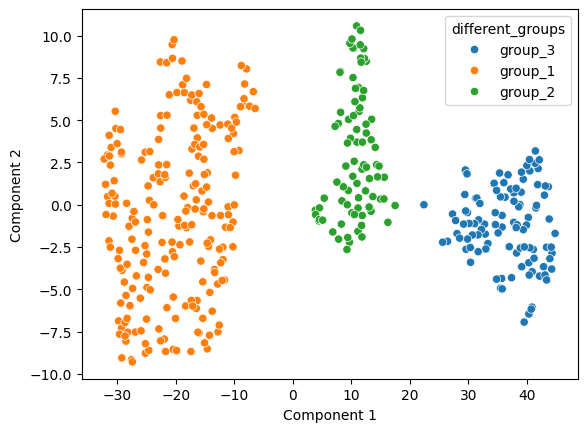

In [27]:
sns.scatterplot(x=reduced_data_df.iloc[:,0],y=reduced_data_df.iloc[:,1],hue=reduced_data_df.iloc[:,2])

In [28]:
df['different_groups'] = reduced_data_df['different_groups'] 

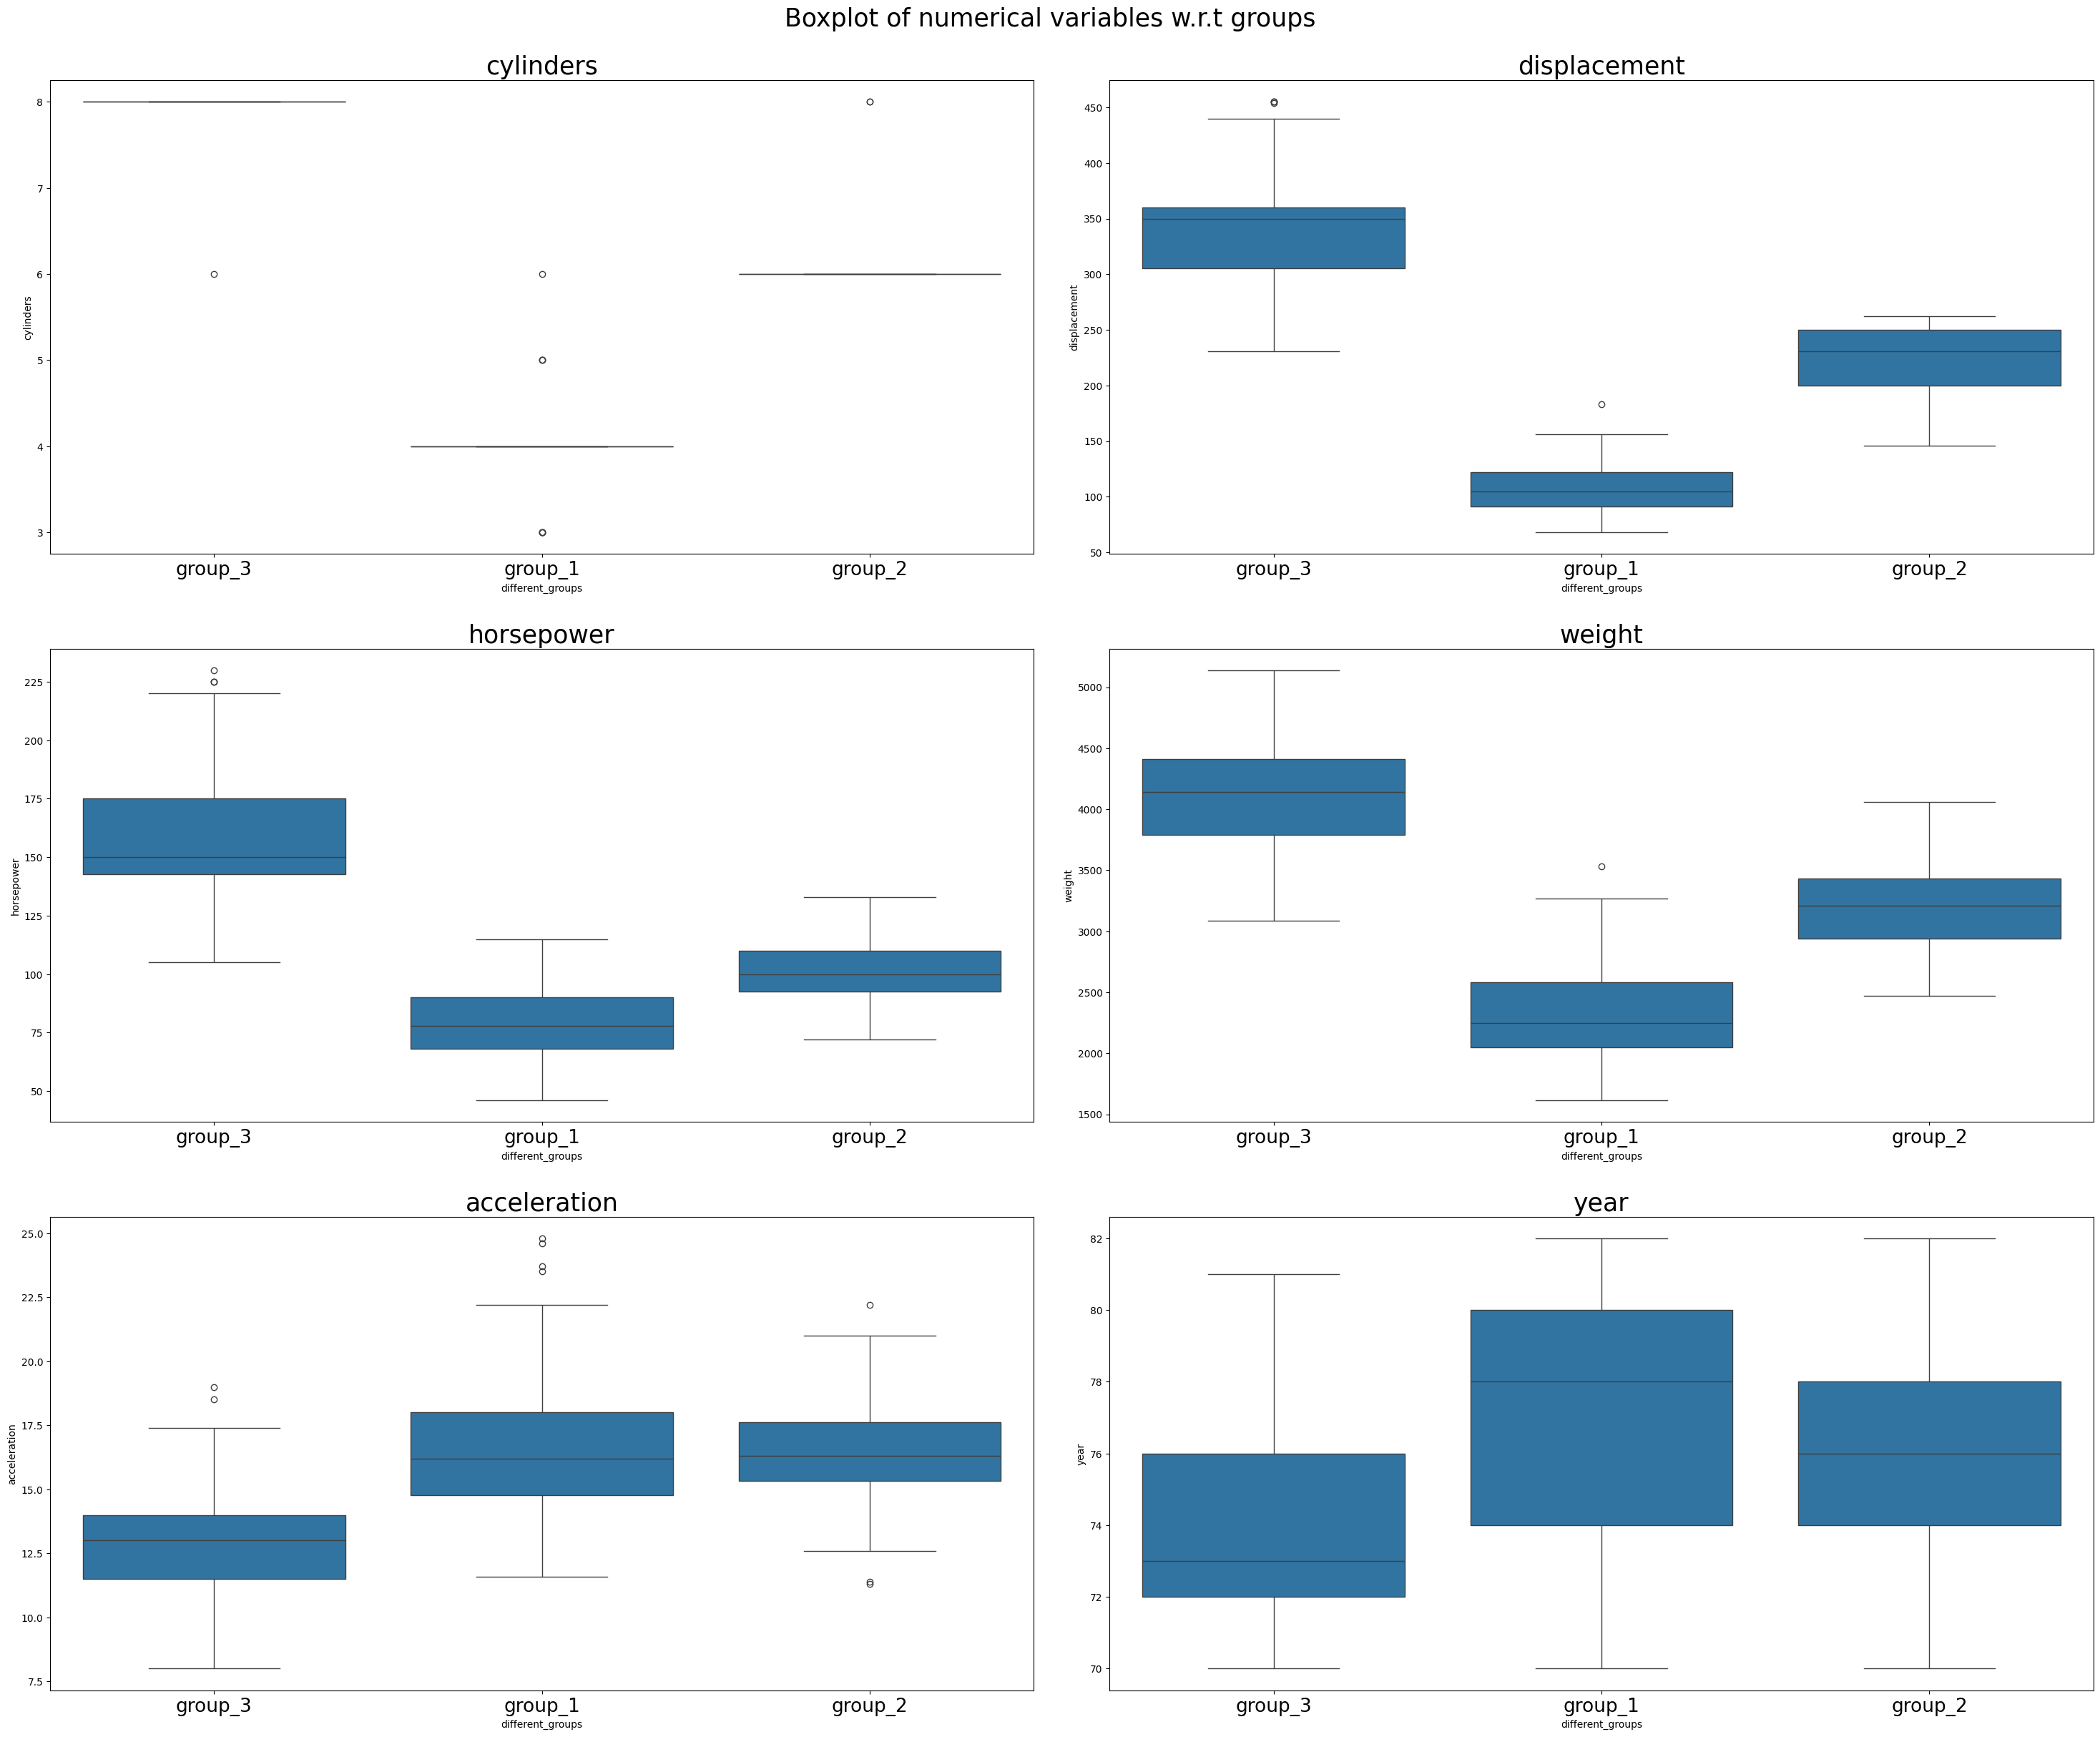

In [34]:
# Lets make boxplot of each numerical variables w.r.t 3 different groups

all_col = df.iloc[:,:-1].columns.tolist()
fig, axes = plt.subplots(3, 2,  figsize=(30, 25))
fig.suptitle('Boxplot of numerical variables w.r.t groups',fontsize = 25)
counter = 0
for ii in range(3):
    sns.boxplot(ax=axes[ii][0],y=df[all_col[counter]],x = df['different_groups'])
    axes[ii][0].set_title(all_col[counter],fontsize = 25)
    axes[ii][0].set_xticklabels( axes[ii][0].get_xmajorticklabels(),fontsize = 19)
    counter = counter+1
    sns.boxplot(ax=axes[ii][1],y=df[all_col[counter]],x = df['different_groups'])
    axes[ii][1].set_title(all_col[counter],fontsize = 25)
    axes[ii][1].set_xticklabels( axes[ii][1].get_xmajorticklabels(),fontsize = 19)
    counter = counter+1
    
fig.tight_layout(pad=3.0)

### Lets us compare mpg (miles per gallon) vs different groups obtained from t-SNE

<Axes: xlabel='different_groups', ylabel='mpg'>

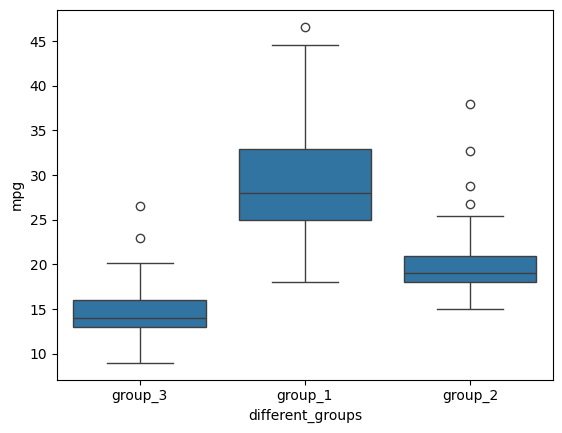

In [35]:
sns.boxplot(y=cData['mpg'], x=df['different_groups'])

### Lets us make scatter plot of first and second component of PCA 

<Axes: xlabel='Component 1', ylabel='Component 2'>

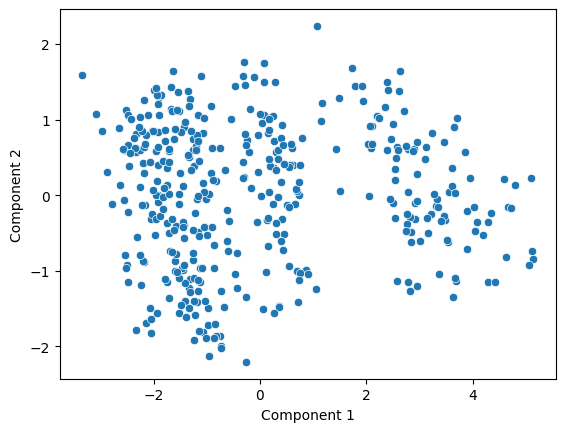

In [39]:
pca = PCA(n_components=2)
X_reduced_pca = pca.fit_transform(X)

reduced_data_df_pca = pd.DataFrame(
    data = X_reduced_pca,
    columns = ['Component 1','Component 2'])
sns.scatterplot(x=reduced_data_df_pca.iloc[:,0],
                y=reduced_data_df_pca.iloc[:,1])

<Axes: xlabel='Component 1', ylabel='Component 2'>

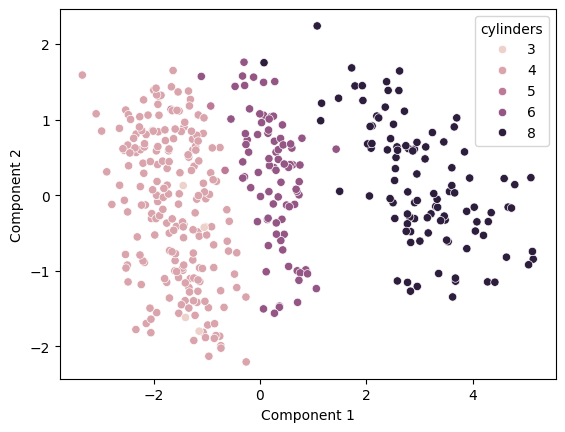

In [40]:
sns.scatterplot(x=reduced_data_df_pca.iloc[:,0],
                y=reduced_data_df_pca.iloc[:,1],hue=cData.cylinders)

**Observations**

- The groups of data points are not as separable as it is case of t-SNE dimensionality reduction


Visualizing the lower dimensional representation of data for different values of perplexity


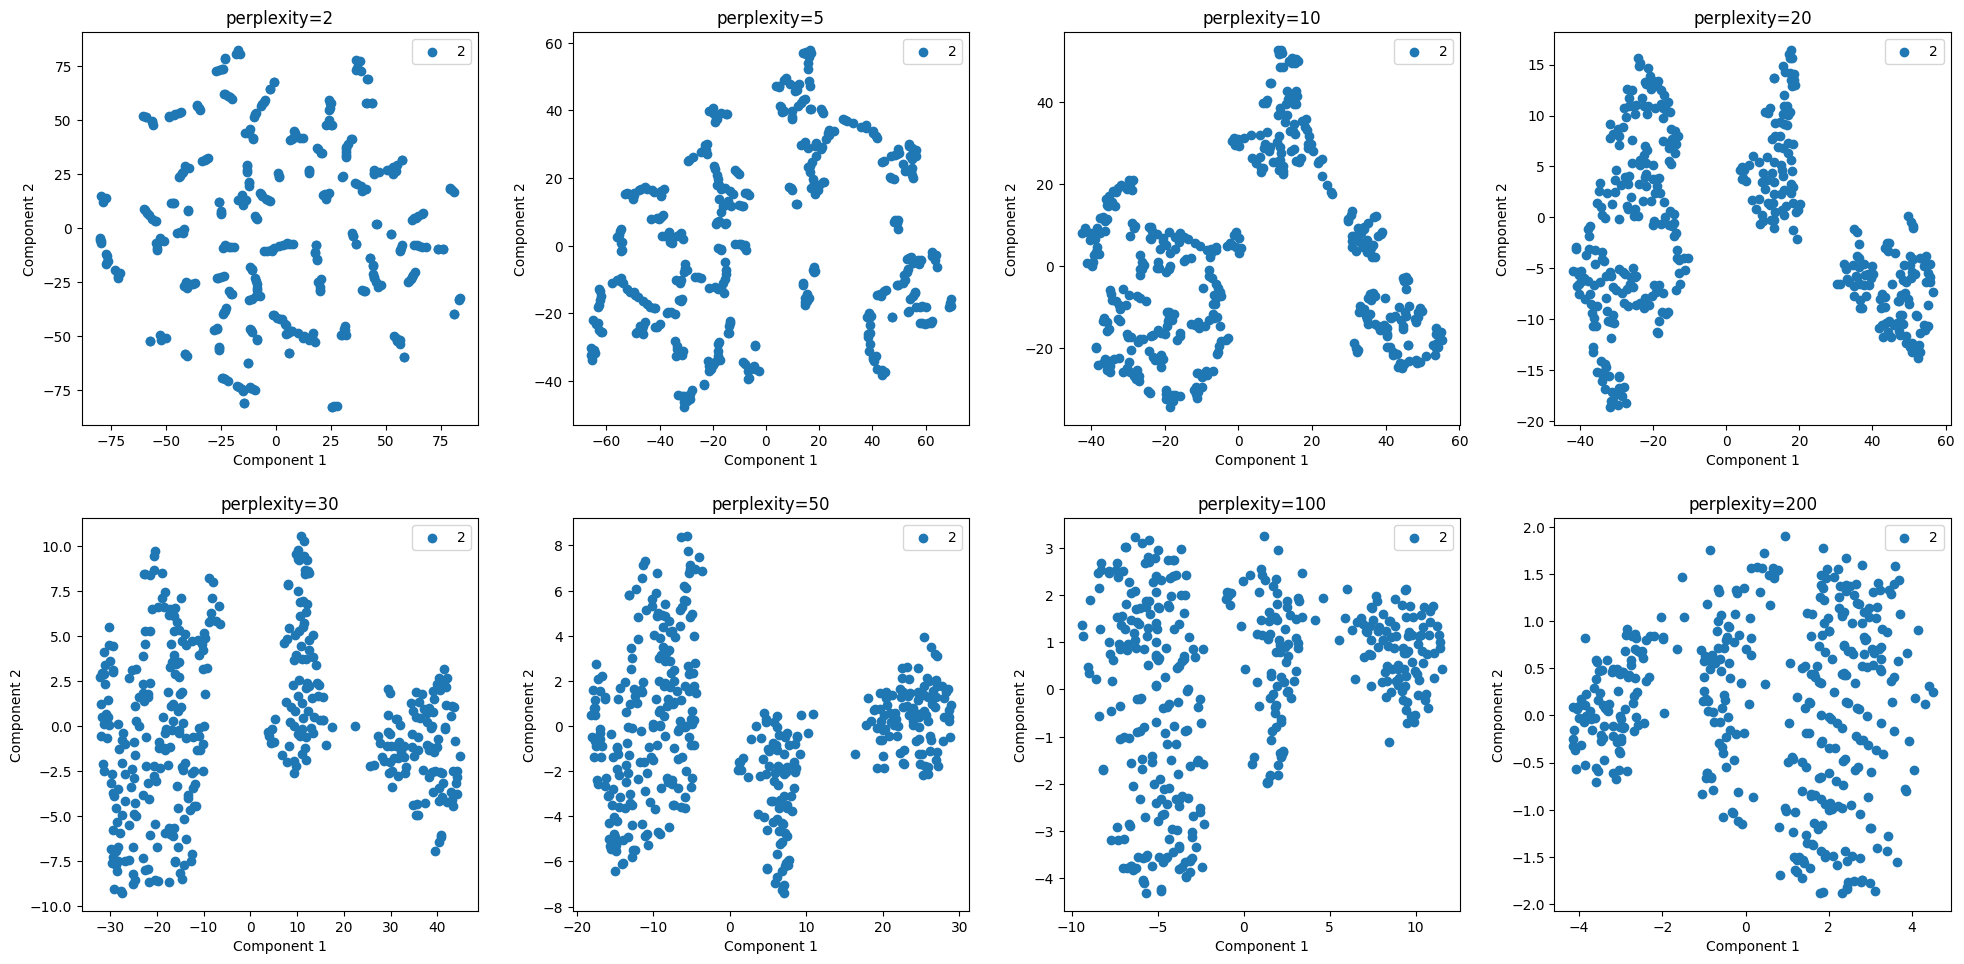

In [46]:
perplexity = [2,5,10,20,30,50,100,200]

plt.figure(figsize=(20,10))
print("Visualizing the lower dimensional representation of data for different values of perplexity")

for i in range(len(perplexity)):
    tsne = TSNE(n_components=2, 
                perplexity=perplexity[i],
                n_jobs=-2,
                random_state=42)
    X_red = tsne.fit_transform(X)
    red_data_df = pd.DataFrame(
        data=X_red,
        columns=['Component 1','Component 2'])
                 
    plt.subplot(2,int(len(perplexity)/2),i+1)             
    
    plt.xlabel('Component 1',fontsize=10)
    plt.ylabel('Component 2',fontsize=10)
    plt.title("perplexity="+str(perplexity[i]))
    plt.scatter(red_data_df.loc[:, 'Component 1'], 
                red_data_df.loc[:, 'Component 2'])#, 
    plt.legend(perplexity,prop={'size': 10})
    plt.tight_layout(pad=2)